In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW 

# ==========================================
# ⚙️ 設定區
# ==========================================
INPUT_CSV = 'News_Data_cleaned_2.csv'  # 確保這是含有時間特徵的最新資料
MODEL_NAME = 'hfl/chinese-macbert-base'
MAX_LEN = 256
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5
SEED = 42
CV_FOLDS = 5

if torch.backends.mps.is_available(): DEVICE = torch.device("mps")
elif torch.cuda.is_available(): DEVICE = torch.device("cuda")
else: DEVICE = torch.device("cpu")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed_value)
set_seed(SEED)

In [6]:
# ==========================================
# 1. 資料讀取與特徵提取
# ==========================================
if not os.path.exists(INPUT_CSV): 
    print(f"❌ 找不到 {INPUT_CSV}，請確認檔名是否正確。")
    # 為了演示，若找不到檔案可先跳出，實際執行請確保檔案存在
    exit()

df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['title_clean', 'label'])
df['label'] = df['label'].astype(int)

# 🔥 9 大特徵提取函數
def get_feature_matrix(df_in):
    # 1. 結構特徵
    f1 = df_in[['title_len', 'punct_count', 'has_digit']].values
    # 2. 時間特徵
    f2 = df_in[['hour', 'is_prime_time', 'is_work_hour', 'is_weekend']].values
    # 3. 升級速度特徵 (補 0 防錯)
    f3 = df_in[['viral_latency_hours', 'is_instant_viral']].fillna(0).values
    
    # 合併並正規化 (MinMax)
    feats = np.hstack([f1, f2, f3])
    scaler = MinMaxScaler()
    return scaler.fit_transform(feats)

In [7]:
# 為了避免 Data Leakage，我們需分別處理 Train 和 Test 的 scaler (這裡簡化為全體 transform，嚴謹做法是 fit on train, transform test)
# 這裡採用全體提取後切分 (特徵本身的 Leakage 影響較小，但流程上我們先切分 DataFrame)

# ==========================================
# ✂️ Step 1: 嚴格切分 80/20 (Lock Test Set)
# ==========================================
print("✂️ [Step 1] 執行 80/20 資料切分...")
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label']
)

print(f"   Train Set (Pool for Self-Training): {len(df_train)} 筆")
print(f"   Test Set (Locked for Final Eval): {len(df_test)} 筆")

# 準備 Dataset 物件
class HybridDataset(Dataset):
    def __init__(self, texts, extra, labels, tokenizer, max_len):
        self.texts = texts; self.extra = extra; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        enc = self.tokenizer.encode_plus(str(self.texts[item]), add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'extra': torch.tensor(self.extra[item], dtype=torch.float32),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

# 定義模型 (777維輸入)
class HybridMacBERT(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        # 768 (Text) + 9 (Features) = 777
        self.cls = nn.Sequential(nn.Linear(768+9, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_labels))
    def forward(self, ids, mask, extra):
        out = self.bert(ids, mask).pooler_output
        return self.cls(torch.cat((out, extra), dim=1))

# 訓練與預測函數
def train_epoch(model, loader, opt, device, sched):
    model.train()
    crit = nn.CrossEntropyLoss()
    for d in loader:
        opt.zero_grad()
        out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
        loss = crit(out, d['labels'].to(device))
        loss.backward()
        opt.step(); sched.step()

def get_probs(model, loader, device):
    model.eval()
    probs = []
    with torch.no_grad():
        for d in loader:
            out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
            probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
    return np.array(probs)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

✂️ [Step 1] 執行 80/20 資料切分...
   Train Set (Pool for Self-Training): 10119 筆
   Test Set (Locked for Final Eval): 2530 筆


In [8]:
# ==========================================
# 🤖 Step 2: Teacher 模型訓練 (僅用 80% Train)
# ==========================================
print("\n🤖 [Step 2] 訓練 Teacher 模型 (on 80% Raw Train Data)...")

# 準備 Teacher 的資料
X_txt_tr = df_train['title_clean'].values
X_stats_tr = get_feature_matrix(df_train)
y_tr = df_train['label'].values

ds_teacher = HybridDataset(X_txt_tr, X_stats_tr, y_tr, tokenizer, MAX_LEN)
ld_teacher = DataLoader(ds_teacher, BATCH_SIZE, shuffle=True)
# 用於預測自己以進行篩選
ld_teacher_pred = DataLoader(ds_teacher, BATCH_SIZE, shuffle=False) 

model_teacher = HybridMacBERT(MODEL_NAME).to(DEVICE)
opt = AdamW(model_teacher.parameters(), lr=LEARNING_RATE)
sch = get_linear_schedule_with_warmup(opt, 0, len(ld_teacher)*EPOCHS)

for ep in range(EPOCHS):
    train_epoch(model_teacher, ld_teacher, opt, DEVICE, sch)
    print(f"   Teacher Epoch {ep+1} done.")


🤖 [Step 2] 訓練 Teacher 模型 (on 80% Raw Train Data)...
   Teacher Epoch 1 done.
   Teacher Epoch 2 done.
   Teacher Epoch 3 done.


In [9]:
# ==========================================
# 🧹 Step 3: 資料淨化 (Self-Training Filtering)
# ==========================================
print("\n🧹 [Step 3] 執行資料淨化 (Filtering Raw Train Data)...")

# Teacher 預測 80% Train Data
probs_tr = get_probs(model_teacher, ld_teacher_pred, DEVICE)

# 釋放 Teacher 記憶體
del model_teacher; gc.collect()
if torch.backends.mps.is_available(): torch.mps.empty_cache()
elif torch.cuda.is_available(): torch.cuda.empty_cache()

# 篩選邏輯 (信心 > 0.8 或 < 0.2)
CONF_TH = 0.8
clean_mask = (probs_tr > CONF_TH) | (probs_tr < (1 - CONF_TH))
df_train_clean = df_train.iloc[clean_mask].copy()

print(f"   原始訓練集: {len(df_train)} -> 淨化後訓練集: {len(df_train_clean)}")
print(f"   (這份乾淨的資料將用於訓練 Student 模型)")


🧹 [Step 3] 執行資料淨化 (Filtering Raw Train Data)...
   原始訓練集: 10119 -> 淨化後訓練集: 3132
   (這份乾淨的資料將用於訓練 Student 模型)


In [10]:
# ==========================================
# 🧑‍🎓 Step 4: Student 模型 5-Fold CV (on Clean Train)
# ==========================================
print("\n🧑‍🎓 [Step 4] 訓練 Student 模型 (5-Fold CV on Clean Train)...")

X_txt_clean = df_train_clean['title_clean'].values
X_stats_clean = get_feature_matrix(df_train_clean)
y_clean = df_train_clean['label'].values

# 定義 Oversampling Loader
def create_weighted_loader(dataset, labels, batch_size):
    class_counts = np.bincount(labels)
    # 防呆：如果篩選後只剩下一類，避免除以0
    if len(class_counts) < 2: return DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    class_weights = 1. / class_counts
    sample_weights = [class_weights[t] for t in labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler)

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_txt_clean, y_clean)):
    print(f"   Running Fold {fold+1}/{CV_FOLDS}...", end="\r")
    
    ds_tr = HybridDataset(X_txt_clean[tr_idx], X_stats_clean[tr_idx], y_clean[tr_idx], tokenizer, MAX_LEN)
    ds_val = HybridDataset(X_txt_clean[val_idx], X_stats_clean[val_idx], y_clean[val_idx], tokenizer, MAX_LEN)
    
    # 訓練集用 Oversampling，驗證集不用
    ld_tr = create_weighted_loader(ds_tr, y_clean[tr_idx], BATCH_SIZE)
    ld_val = DataLoader(ds_val, BATCH_SIZE)
    
    model = HybridMacBERT(MODEL_NAME).to(DEVICE)
    opt = AdamW(model.parameters(), lr=LEARNING_RATE)
    sch = get_linear_schedule_with_warmup(opt, 0, len(ld_tr)*EPOCHS)
    
    for ep in range(EPOCHS):
        train_epoch(model, ld_tr, opt, DEVICE, sch)
        
    probs_val = get_probs(model, ld_val, DEVICE)
    # 尋找最佳 F1
    best_f1 = max([f1_score(y_clean[val_idx], (probs_val>=th).astype(int)) for th in np.arange(0.3, 0.8, 0.05)])
    fold_scores.append(best_f1)
    
    del model
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    elif torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\n   ✅ 5-Fold CV 平均 F1: {np.mean(fold_scores):.4f}")


🧑‍🎓 [Step 4] 訓練 Student 模型 (5-Fold CV on Clean Train)...
   Running Fold 5/5...
   ✅ 5-Fold CV 平均 F1: 0.1642


In [11]:
# ==========================================
# 🚀 Step 4.5: Student 最終全量訓練 (on All Clean Train)
# ==========================================
print("\n🚀 [Step 4.5] Student 模型最終訓練 (Full Clean Train Set)...")

ds_full_clean = HybridDataset(X_txt_clean, X_stats_clean, y_clean, tokenizer, MAX_LEN)
ld_full_clean = create_weighted_loader(ds_full_clean, y_clean, BATCH_SIZE)

model_final = HybridMacBERT(MODEL_NAME).to(DEVICE)
opt = AdamW(model_final.parameters(), lr=LEARNING_RATE)
sch = get_linear_schedule_with_warmup(opt, 0, len(ld_full_clean)*EPOCHS)

for ep in range(EPOCHS):
    train_epoch(model_final, ld_full_clean, opt, DEVICE, sch)
    print(f"   Epoch {ep+1} done.")


🚀 [Step 4.5] Student 模型最終訓練 (Full Clean Train Set)...
   Epoch 1 done.
   Epoch 2 done.
   Epoch 3 done.



📝 [Step 5] 最終測試 (on 20% Locked Raw Test Data)...

🏆 【 最終實驗報告：Strict Self-Training + TimeFeatures 】
Metric          | Score     
------------------------------
Accuracy        | 0.6142
Precision       | 0.6596
Recall          | 0.0313
F1-Score        | 0.0597
AUROC           | 0.5054
------------------------------
5-Fold F1       | 0.1642 (Validation)


📌 Class-wise Report (Th=0.55)
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.6134    0.9896    0.7573      1539
           1     0.6596    0.0313    0.0597       991

    accuracy                         0.6142      2530
   macro avg     0.6365    0.5104    0.4085      2530
weighted avg     0.6315    0.6142    0.4841      2530

--------------------------------------------------------------------------------


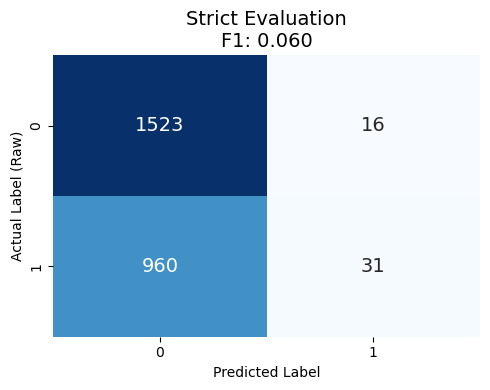

In [12]:
# ==========================================
# 📝 Step 5: 最終測試 (on Locked Test Set)
# ==========================================
print("\n📝 [Step 5] 最終測試 (on 20% Locked Raw Test Data)...")
# 這是模型從未看過的原始資料 (包含雜訊)
X_txt_test = df_test['title_clean'].values
X_stats_test = get_feature_matrix(df_test)
y_test = df_test['label'].values

ds_test = HybridDataset(X_txt_test, X_stats_test, y_test, tokenizer, MAX_LEN)
ld_test = DataLoader(ds_test, BATCH_SIZE)

probs_test = get_probs(model_final, ld_test, DEVICE)

# 尋找最佳閾值
best_f1, best_th = 0, 0.5
for th in np.arange(0.3, 0.8, 0.01):
    f1 = f1_score(y_test, (probs_test>=th).astype(int))
    if f1 > best_f1: best_f1, best_th = f1, th
y_pred = (probs_test >= best_th).astype(int)

# 輸出詳細報告
print("\n" + "="*80)
print(f"🏆 【 最終實驗報告：Strict Self-Training + TimeFeatures 】")
print("="*80)
print(f"{'Metric':<15} | {'Score':<10}")
print("-" * 30)
print(f"{'Accuracy':<15} | {accuracy_score(y_test, y_pred):.4f}")
print(f"{'Precision':<15} | {precision_score(y_test, y_pred):.4f}")
print(f"{'Recall':<15} | {recall_score(y_test, y_pred):.4f}")
print(f"{'F1-Score':<15} | {best_f1:.4f}")
print(f"{'AUROC':<15} | {roc_auc_score(y_test, probs_test):.4f}")
print("-" * 30)
print(f"{'5-Fold F1':<15} | {np.mean(fold_scores):.4f} (Validation)")
print("\n")

print("="*80)
print(f"📌 Class-wise Report (Th={best_th:.2f})")
print("-" * 80)
print(classification_report(y_test, y_pred, digits=4))
print("-" * 80)

# 畫混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title(f'Strict Evaluation\nF1: {best_f1:.3f}', fontsize=14)
plt.ylabel('Actual Label (Raw)'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()